# Rare Disease Inheritance Prediction Pipeline

This notebook imports and audits the referenced `rare_diseases_complete.csv` dataset, performs exploratory analysis and feature engineering, creates a held-out test set, compares a majority-class benchmark with cross-validated logistic regression, random forest, and multilayer perceptron models, selects a champion using training-fold performance, and generates candidate predictions for records whose inheritance label is missing.

# 1. Environment and Data Import

In [26]:
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import (
    LogisticRegression,
    MultilayerPerceptronClassifier,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import (
    IndexToString,
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
MIN_CLASS_COUNT = 20

spark = (
    SparkSession.builder
    .appName("RareDiseaseInheritancePrediction")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

In [13]:
DATA_PATH = "rare_diseases_complete.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(DATA_PATH)
)

print(f"Rows: {df.count():,}")
print(f"Columns: {len(df.columns)}")
df.printSchema()
df.show(5, truncate=False)

Rows: 11,456
Columns: 15
root
 |-- OrphaCode: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- DisorderType: string (nullable = true)
 |-- DisorderGroup: string (nullable = true)
 |-- ICD-11: string (nullable = true)
 |-- MONDO: integer (nullable = true)
 |-- ICD-10: string (nullable = true)
 |-- OMIM: integer (nullable = true)
 |-- UMLS: string (nullable = true)
 |-- MeSH: string (nullable = true)
 |-- MedDRA: integer (nullable = true)
 |-- GARD: integer (nullable = true)
 |-- DiseaseName: string (nullable = true)
 |-- AgeOfOnset: string (nullable = true)
 |-- TypeOfInheritance: string (nullable = true)

+---------+------------------------------------------------------------------------+------------+-------------+-------+-----+------+------+--------+-------+--------+----+------------------------------------------------------------------------+----------------------------+-------------------+
|OrphaCode|Name                                                             

# 2. Exploratory Data Analysis

In [14]:
distinct_rows = [
    {"feature": column_name, "distinct_values": df.select(column_name).distinct().count()}
    for column_name in df.columns
]
spark.createDataFrame(distinct_rows).orderBy(F.desc("distinct_values")).show(30, truncate=False)

+---------------+-----------------+
|distinct_values|feature          |
+---------------+-----------------+
|11456          |OrphaCode        |
|11456          |Name             |
|9631           |UMLS             |
|7989           |MONDO            |
|7375           |DiseaseName      |
|4421           |OMIM             |
|3834           |GARD             |
|3217           |MeSH             |
|2280           |ICD-11           |
|1806           |MedDRA           |
|1744           |ICD-10           |
|68             |TypeOfInheritance|
|63             |AgeOfOnset       |
|11             |DisorderType     |
|3              |DisorderGroup    |
+---------------+-----------------+



,feature,missing_count,missing_percent
10,MedDRA,9651,84.24
9,MeSH,8240,71.93
11,GARD,7623,66.54
7,OMIM,6478,56.55
4,ICD-11,5313,46.38
14,TypeOfInheritance,5218,45.55
13,AgeOfOnset,4675,40.81
12,DiseaseName,4082,35.63
6,ICD-10,3915,34.17
5,MONDO,3468,30.27


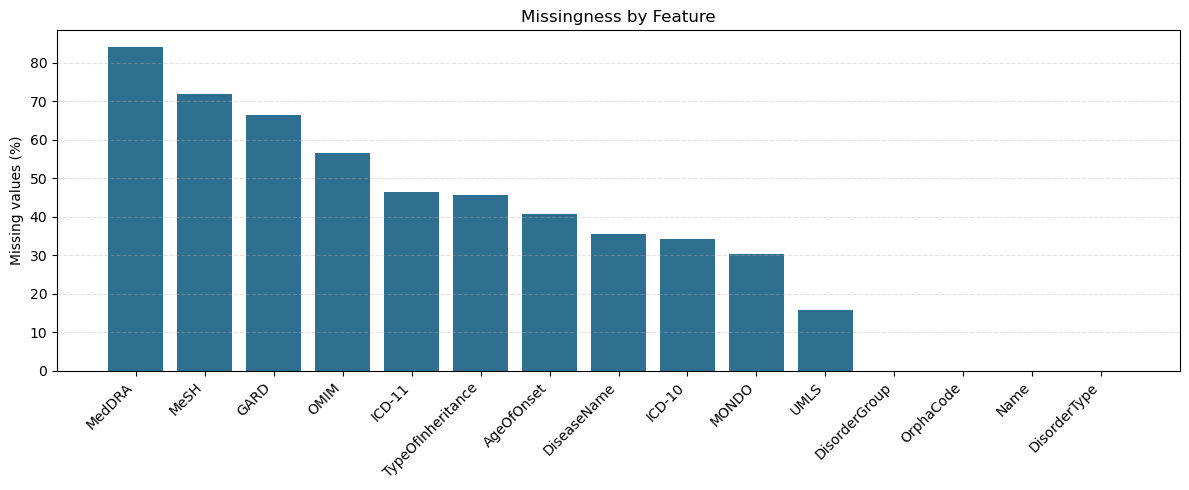

In [15]:
total_rows = df.count()
missing_rows = []
for column_name in df.columns:
    missing_count = df.filter(F.col(column_name).isNull()).count()
    missing_rows.append(
        {
            "feature": column_name,
            "missing_count": missing_count,
            "missing_percent": round(100.0 * missing_count / total_rows, 2),
        }
    )

missing_pdf = pd.DataFrame(missing_rows).sort_values("missing_percent", ascending=False)
display(missing_pdf)

plt.figure(figsize=(12, 5))
plt.bar(missing_pdf["feature"], missing_pdf["missing_percent"], color="#2f6f8f")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing values (%)")
plt.title("Missingness by Feature")
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

,TypeOfInheritance,count
0,Missing target,5218
1,Autosomal recessive,2141
2,Autosomal dominant,1355
3,Not applicable,1179
4,X-linked recessive,257
5,Unknown,257
6,"Autosomal dominant, Autosomal recessive",251
7,"Autosomal dominant, Not applicable",151
8,"Multigenic/multifactorial, Not applicable",88
9,"Not applicable, Unknown",86


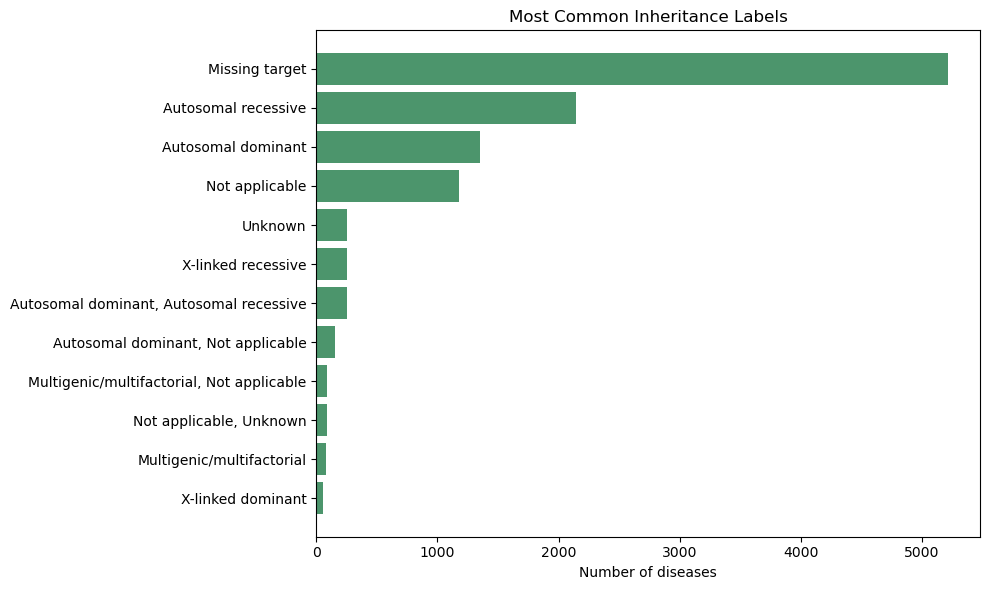

In [16]:
target_distribution_pdf = (
    df.groupBy("TypeOfInheritance")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
target_distribution_pdf["TypeOfInheritance"] = target_distribution_pdf[
    "TypeOfInheritance"
].fillna("Missing target")

display(target_distribution_pdf.head(20))

top_targets = target_distribution_pdf.head(12).sort_values("count")
plt.figure(figsize=(10, 6))
plt.barh(top_targets["TypeOfInheritance"], top_targets["count"], color="#4c956c")
plt.xlabel("Number of diseases")
plt.title("Most Common Inheritance Labels")
plt.tight_layout()
plt.show()

# 3. Preprocessing and Train/Test Split

Missing predictor values are represented explicitly, code identifiers are converted to availability indicators rather than treated as numeric quantities, and missing target labels are preserved for later prediction. The labeled data are split before rare target labels are grouped, so test-set information is not used to define the modeling classes.

In [17]:
categorical_cols = ["DisorderType", "DisorderGroup", "AgeOfOnset"]
target_col = "TypeOfInheritance"
code_system_cols = ["ICD-11", "MONDO", "ICD-10", "OMIM", "UMLS", "MeSH", "MedDRA", "GARD"]
code_feature_cols = [
    "has_icd11", "has_mondo", "has_icd10", "has_omim",
    "has_umls", "has_mesh", "has_meddra", "has_gard",
]

modeling_df = df
for column_name in categorical_cols + [target_col]:
    normalized = F.trim(F.col(column_name).cast("string"))
    modeling_df = modeling_df.withColumn(
        column_name,
        F.when(normalized.isNull() | (normalized == ""), F.lit(None)).otherwise(normalized),
    )

modeling_df = modeling_df.fillna("Unknown", subset=categorical_cols)
modeling_df = modeling_df.withColumn(
    "DisplayDiseaseName",
    F.coalesce(F.col("DiseaseName"), F.col("Name"), F.lit("Unknown disease")),
)

for source_column, feature_column in zip(code_system_cols, code_feature_cols):
    modeling_df = modeling_df.withColumn(
        feature_column,
        F.when(F.col(source_column).isNotNull(), F.lit(1.0)).otherwise(F.lit(0.0)),
    )

modeling_df = modeling_df.withColumn(
    "code_system_count",
    sum((F.col(column_name) for column_name in code_feature_cols), F.lit(0.0)),
)

raw_labeled_df = modeling_df.filter(F.col(target_col).isNotNull())
unlabeled_df = modeling_df.filter(F.col(target_col).isNull())
train_raw, test_raw = raw_labeled_df.randomSplit([0.8, 0.2], seed=SEED)

print(f"Total rows: {modeling_df.count():,}")
print(f"Raw labeled rows: {raw_labeled_df.count():,}")
print(f"Training rows before class grouping: {train_raw.count():,}")
print(f"Held-out test rows: {test_raw.count():,}")
print(f"Missing-target rows retained for prediction: {unlabeled_df.count():,}")

Total rows: 11,456
Raw labeled rows: 6,238
Training rows before class grouping: 5,045
Held-out test rows: 1,193
Missing-target rows retained for prediction: 5,218


In [18]:
# Defining sufficiently supported labels using training data only.
training_class_counts = train_raw.groupBy(target_col).count()
common_labels = [
    row[target_col]
    for row in training_class_counts.filter(F.col("count") >= MIN_CLASS_COUNT).collect()
]

def add_model_target(frame):
    return frame.withColumn(
        "ModelTarget",
        F.when(F.col(target_col).isin(common_labels), F.col(target_col))
        .otherwise(F.lit("Other rare/combined")),
    )

train_targeted = add_model_target(train_raw)
test_targeted = add_model_target(test_raw)

label_indexer_model = StringIndexer(
    inputCol="ModelTarget",
    outputCol="label",
    handleInvalid="error",
    stringOrderType="frequencyDesc",
).fit(train_targeted)

train_data = label_indexer_model.transform(train_targeted).cache()
test_data = label_indexer_model.transform(test_targeted).cache()

print(f"Training-supported raw labels: {len(common_labels)}")
print(f"Final modeled classes: {len(label_indexer_model.labels)}")
train_data.groupBy("ModelTarget").count().orderBy(F.desc("count")).show(30, truncate=False)

Training-supported raw labels: 14
Final modeled classes: 15
+-----------------------------------------------------------+-----+
|ModelTarget                                                |count|
+-----------------------------------------------------------+-----+
|Autosomal recessive                                        |1742 |
|Autosomal dominant                                         |1089 |
|Not applicable                                             |946  |
|Unknown                                                    |207  |
|Autosomal dominant, Autosomal recessive                    |204  |
|X-linked recessive                                         |199  |
|Other rare/combined                                        |183  |
|Autosomal dominant, Not applicable                         |120  |
|Multigenic/multifactorial, Not applicable                  |71   |
|Multigenic/multifactorial                                  |70   |
|Not applicable, Unknown                                

# 4. Feature Pipeline

Categorical predictors are indexed and one-hot encoded. Code-system availability indicators and their count are assembled with the encoded predictors, then standardized. The feature transformer is fitted on training data only and frozen before cross-validation so every fold, including the fixed-width MLP input layer, uses the same vector schema.

In [19]:
indexed_cols = [f"{column_name}_Index" for column_name in categorical_cols]
encoded_cols = [f"{column_name}_Vec" for column_name in categorical_cols]

def make_feature_stages():
    stages = [
        StringIndexer(
            inputCol=column_name,
            outputCol=f"{column_name}_Index",
            handleInvalid="keep",
            stringOrderType="frequencyDesc",
        )
        for column_name in categorical_cols
    ]
    stages.extend(
        [
            OneHotEncoder(inputCols=indexed_cols, outputCols=encoded_cols),
            VectorAssembler(
                inputCols=code_feature_cols + ["code_system_count"] + encoded_cols,
                outputCol="raw_features",
            ),
            StandardScaler(
                inputCol="raw_features",
                outputCol="features",
                withStd=True,
                withMean=False,
            ),
        ]
    )
    return stages

# Fitting the feature transformer on training data only and preserving a fixed vector width across CV folds.
feature_pipeline_model = Pipeline(stages=make_feature_stages()).fit(train_data)
transformed_train_data = feature_pipeline_model.transform(train_data).cache()
transformed_test_data = feature_pipeline_model.transform(test_data).cache()
transformed_unlabeled_df = feature_pipeline_model.transform(unlabeled_df).cache()

num_features = transformed_train_data.select("features").first()[0].size
num_classes = len(label_indexer_model.labels)

print(f"Final feature-vector size: {num_features}")
print(f"Number of target classes: {num_classes}")

Final feature-vector size: 77
Number of target classes: 15


# 5. Model Construction and K-Fold Cross-Validation

Four models are assessed: a majority-class benchmark and three trained candidates. Logistic regression, random forest, and multilayer perceptron hyperparameters are selected using three-fold cross-validation on training data only.

In [20]:
cv_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    family="multinomial",
    maxIter=80,
    elasticNetParam=0.0,
)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.05])
    .build()
)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=SEED,
    subsamplingRate=0.85,
)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [40, 80])
    .addGrid(rf.maxDepth, [5, 8])
    .build()
)

mlp_layers = [num_features, 32, 16, num_classes]
mlp = MultilayerPerceptronClassifier(
    labelCol="label",
    featuresCol="features",
    layers=mlp_layers,
    maxIter=50,
    blockSize=128,
    seed=SEED,
)
mlp_grid = (
    ParamGridBuilder()
    .addGrid(
        mlp.layers,
        [
            [num_features, 16, num_classes],
            [num_features, 32, 16, num_classes],
        ],
    )
    .build()
)

cv_jobs = {
    "logistic_regression": CrossValidator(
        estimator=lr,
        estimatorParamMaps=lr_grid,
        evaluator=cv_evaluator,
        numFolds=3,
        parallelism=2,
        seed=SEED,
    ),
    "random_forest": CrossValidator(
        estimator=rf,
        estimatorParamMaps=rf_grid,
        evaluator=cv_evaluator,
        numFolds=3,
        parallelism=2,
        seed=SEED,
    ),
    "multilayer_perceptron": CrossValidator(
        estimator=mlp,
        estimatorParamMaps=mlp_grid,
        evaluator=cv_evaluator,
        numFolds=3,
        parallelism=2,
        seed=SEED,
    ),
}

print("Cross-validation jobs prepared:", ", ".join(cv_jobs))

Cross-validation jobs prepared: logistic_regression, random_forest, multilayer_perceptron


In [21]:
cv_models = {}
sensitivity_rows = []
best_cv_scores = {}

for model_name, cv_job in cv_jobs.items():
    print(f"Training {model_name} with 3-fold cross-validation...")
    cv_model = cv_job.fit(transformed_train_data)
    cv_models[model_name] = cv_model
    best_cv_scores[model_name] = max(float(value) for value in cv_model.avgMetrics)

    for parameter_map, metric_value in zip(
        cv_model.getEstimatorParamMaps(), cv_model.avgMetrics
    ):
        parameter_text = ", ".join(
            f"{parameter.name}={value}" for parameter, value in parameter_map.items()
        )
        sensitivity_rows.append(
            {
                "model": model_name,
                "parameters": parameter_text,
                "cv_weighted_f1": round(float(metric_value), 4),
            }
        )
    print(f"Best CV weighted F1 for {model_name}: {best_cv_scores[model_name]:.4f}")

sensitivity_df = spark.createDataFrame(sensitivity_rows)
sensitivity_df.orderBy("model", F.desc("cv_weighted_f1")).show(50, truncate=False)

champion_model_name = max(best_cv_scores, key=best_cv_scores.get)
champion_model = cv_models[champion_model_name]
print(f"Champion selected from training-fold performance: {champion_model_name}")

Training logistic_regression with 3-fold cross-validation...
Best CV weighted F1 for logistic_regression: 0.4147
Training random_forest with 3-fold cross-validation...
Best CV weighted F1 for random_forest: 0.3719
Training multilayer_perceptron with 3-fold cross-validation...
Best CV weighted F1 for multilayer_perceptron: 0.4105
+--------------+---------------------+-----------------------+
|cv_weighted_f1|model                |parameters             |
+--------------+---------------------+-----------------------+
|0.4147        |logistic_regression  |regParam=0.01          |
|0.4066        |logistic_regression  |regParam=0.05          |
|0.4105        |multilayer_perceptron|layers=[77, 32, 16, 15]|
|0.4099        |multilayer_perceptron|layers=[77, 16, 15]    |
|0.3719        |random_forest        |numTrees=40, maxDepth=8|
|0.3651        |random_forest        |numTrees=80, maxDepth=8|
|0.3417        |random_forest        |numTrees=80, maxDepth=5|
|0.3298        |random_forest        |n

# 6. Held-Out Model Evaluation

In [22]:
evaluators = {
    "accuracy": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ),
    "weighted_precision": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
    ),
    "weighted_recall": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall"
    ),
    "weighted_f1": MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    ),
}

binary_auc_evaluator = BinaryClassificationEvaluator(
    labelCol="binary_label",
    rawPredictionCol="class_probability",
    metricName="areaUnderROC",
)

def macro_ovr_auc(predictions, class_count):
    probability_frame = predictions.withColumn(
        "probability_array", vector_to_array(F.col("probability"))
    )
    auc_values = []
    for class_index in range(class_count):
        one_vs_rest = probability_frame.select(
            F.when(F.col("label") == float(class_index), F.lit(1.0))
            .otherwise(F.lit(0.0))
            .alias("binary_label"),
            F.col("probability_array")[class_index].alias("class_probability"),
        )
        counts = one_vs_rest.agg(
            F.sum("binary_label").alias("positive_count"),
            F.count("*").alias("row_count"),
        ).first()
        if 0 < counts["positive_count"] < counts["row_count"]:
            auc_values.append(float(binary_auc_evaluator.evaluate(one_vs_rest)))
    return sum(auc_values) / len(auc_values) if auc_values else None

train_target_counts = transformed_train_data.groupBy("label").count().collect()
majority_label = float(max(train_target_counts, key=lambda row: row["count"])["label"])
baseline_predictions = transformed_test_data.withColumn("prediction", F.lit(majority_label))

test_predictions = {
    model_name: cv_model.transform(transformed_test_data).cache()
    for model_name, cv_model in cv_models.items()
}

metric_rows = [
    {
        "model": "majority_class_baseline",
        "cv_weighted_f1": None,
        "accuracy": round(float(evaluators["accuracy"].evaluate(baseline_predictions)), 4),
        "weighted_precision": round(float(evaluators["weighted_precision"].evaluate(baseline_predictions)), 4),
        "weighted_recall": round(float(evaluators["weighted_recall"].evaluate(baseline_predictions)), 4),
        "weighted_f1": round(float(evaluators["weighted_f1"].evaluate(baseline_predictions)), 4),
        "macro_ovr_auc": 0.5,
    }
]

for model_name, predictions in test_predictions.items():
    metric_rows.append(
        {
            "model": model_name,
            "cv_weighted_f1": round(best_cv_scores[model_name], 4),
            **{
                metric_name: round(float(evaluator.evaluate(predictions)), 4)
                for metric_name, evaluator in evaluators.items()
            },
            "macro_ovr_auc": round(macro_ovr_auc(predictions, num_classes), 4),
        }
    )

metrics_df = spark.createDataFrame(metric_rows).select(
    "model",
    "cv_weighted_f1",
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_ovr_auc",
)
metrics_df.orderBy(F.desc("weighted_f1")).show(truncate=False)

champion_predictions = test_predictions[champion_model_name]
champion_metric_row = next(row for row in metric_rows if row["model"] == champion_model_name)

+-----------------------+--------------+--------+------------------+---------------+-----------+-------------+
|model                  |cv_weighted_f1|accuracy|weighted_precision|weighted_recall|weighted_f1|macro_ovr_auc|
+-----------------------+--------------+--------+------------------+---------------+-----------+-------------+
|multilayer_perceptron  |0.4105        |0.5113  |0.3978            |0.5113         |0.4294     |0.7237       |
|logistic_regression    |0.4147        |0.5029  |0.4095            |0.5029         |0.4241     |0.7614       |
|random_forest          |0.3719        |0.4987  |0.4141            |0.4987         |0.3823     |0.7584       |
|majority_class_baseline|NULL          |0.3345  |0.1119            |0.3345         |0.1676     |0.5          |
+-----------------------+--------------+--------+------------------+---------------+-----------+-------------+



+-----------+-----------------------------------------------------------+-------+---------+------+------+
|class_index|inheritance_label                                          |support|precision|recall|f1    |
+-----------+-----------------------------------------------------------+-------+---------+------+------+
|0          |Autosomal recessive                                        |399    |0.4835   |0.807 |0.6047|
|1          |Autosomal dominant                                         |266    |0.4588   |0.3346|0.387 |
|2          |Not applicable                                             |233    |0.5881   |0.8026|0.6788|
|5          |X-linked recessive                                         |58     |0.0      |0.0   |0.0   |
|3          |Unknown                                                    |50     |0.1111   |0.02  |0.0339|
|4          |Autosomal dominant, Autosomal recessive                    |47     |0.0      |0.0   |0.0   |
|6          |Other rare/combined              

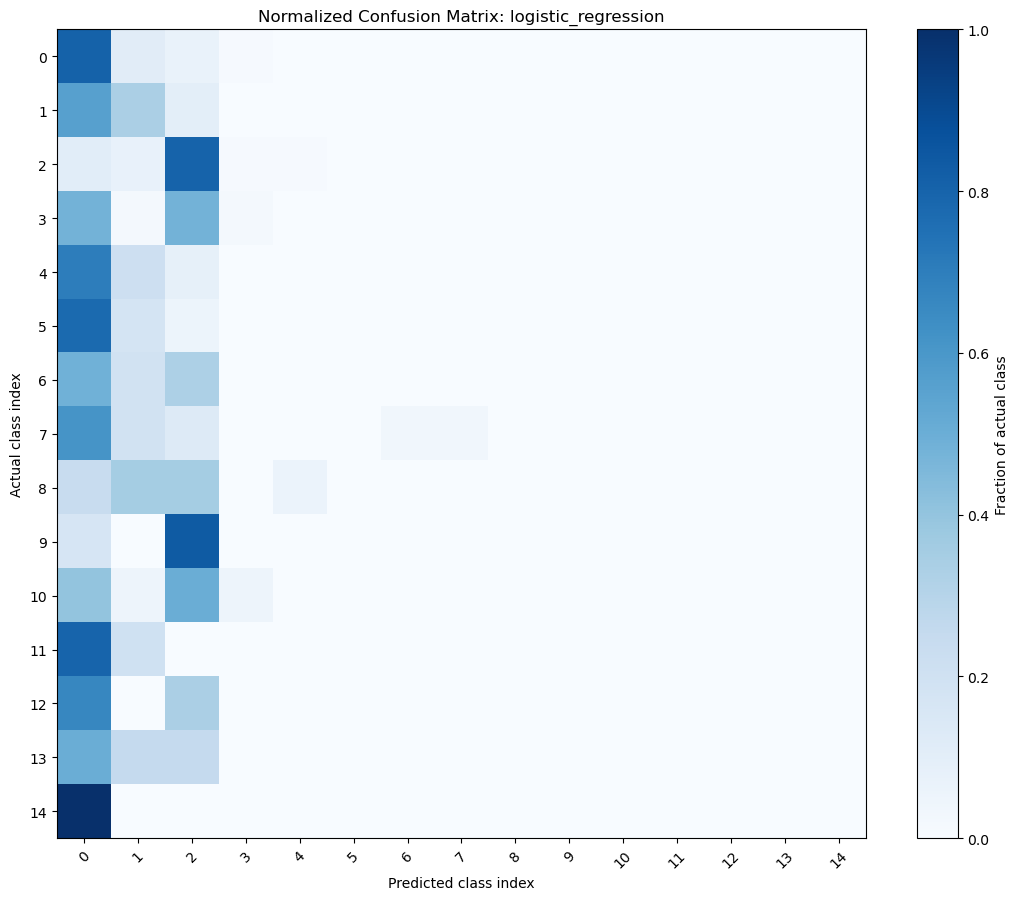

+-----------+-----------------------------------------------------------+
|class_index|inheritance_label                                          |
+-----------+-----------------------------------------------------------+
|0          |Autosomal recessive                                        |
|1          |Autosomal dominant                                         |
|2          |Not applicable                                             |
|3          |Unknown                                                    |
|4          |Autosomal dominant, Autosomal recessive                    |
|5          |X-linked recessive                                         |
|6          |Other rare/combined                                        |
|7          |Autosomal dominant, Not applicable                         |
|8          |Multigenic/multifactorial, Not applicable                  |
|9          |Multigenic/multifactorial                                  |
|10         |Not applicable, Unknown  

In [23]:
# Champion per-class metrics and normalized confusion matrix.
confusion_counts = (
    champion_predictions
    .select(F.col("label").cast("int"), F.col("prediction").cast("int"))
    .groupBy("label", "prediction")
    .count()
    .collect()
)

confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
for row in confusion_counts:
    confusion_matrix[row["label"], row["prediction"]] = row["count"]

per_class_rows = []
for class_index, class_name in enumerate(label_indexer_model.labels):
    true_positive = confusion_matrix[class_index, class_index]
    false_positive = confusion_matrix[:, class_index].sum() - true_positive
    false_negative = confusion_matrix[class_index, :].sum() - true_positive
    support = confusion_matrix[class_index, :].sum()
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    per_class_rows.append(
        {
            "class_index": class_index,
            "inheritance_label": class_name,
            "support": int(support),
            "precision": round(float(precision), 4),
            "recall": round(float(recall), 4),
            "f1": round(float(f1), 4),
        }
    )

per_class_df = spark.createDataFrame(per_class_rows).select(
    "class_index", "inheritance_label", "support", "precision", "recall", "f1"
)
per_class_df.orderBy(F.desc("support")).show(50, truncate=False)

row_totals = confusion_matrix.sum(axis=1, keepdims=True)
normalized_confusion = np.divide(
    confusion_matrix,
    row_totals,
    out=np.zeros_like(confusion_matrix, dtype=float),
    where=row_totals != 0,
)

plt.figure(figsize=(11, 9))
image = plt.imshow(normalized_confusion, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(image, label="Fraction of actual class")
plt.xticks(range(num_classes), range(num_classes), rotation=45)
plt.yticks(range(num_classes), range(num_classes))
plt.xlabel("Predicted class index")
plt.ylabel("Actual class index")
plt.title(f"Normalized Confusion Matrix: {champion_model_name}")
plt.tight_layout()
plt.show()

label_mapping_df = spark.createDataFrame(
    [(index, label) for index, label in enumerate(label_indexer_model.labels)],
    ["class_index", "inheritance_label"],
)
label_mapping_df.show(50, truncate=False)

# 7. Prediction Outputs

In [24]:
label_decoder = IndexToString(
    inputCol="prediction",
    outputCol="Predicted_Inheritance",
    labels=label_indexer_model.labels,
)

decoded_test_predictions = label_decoder.transform(champion_predictions).withColumn(
    "Prediction_Confidence",
    F.array_max(vector_to_array(F.col("probability"))),
)

test_prediction_output = decoded_test_predictions.select(
    "OrphaCode",
    F.col("DisplayDiseaseName").alias("DiseaseName"),
    F.col(target_col).alias("Actual_Inheritance"),
    "Predicted_Inheritance",
    "Prediction_Confidence",
)

scored_unlabeled = champion_model.transform(transformed_unlabeled_df)
decoded_unlabeled = label_decoder.transform(scored_unlabeled).withColumn(
    "Prediction_Confidence",
    F.array_max(vector_to_array(F.col("probability"))),
)

unlabeled_prediction_output = decoded_unlabeled.select(
    "OrphaCode",
    F.col("DisplayDiseaseName").alias("DiseaseName"),
    "Predicted_Inheritance",
    "Prediction_Confidence",
)

output_frames = {
    "model_metrics": metrics_df,
    "hyperparameter_sensitivity": sensitivity_df,
    "champion_per_class_metrics": per_class_df,
    "class_label_mapping": label_mapping_df,
    "rare_diseases_test_predictions": test_prediction_output,
    "rare_diseases_unlabeled_predictions": unlabeled_prediction_output,
}

# These reporting tables are small, so export them as ordinary CSV files.
# This avoids platform-specific Spark CSV writer failures during overwrite.
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)
output_files = {}

for output_name, output_frame in output_frames.items():
    output_file = output_dir / f"{output_name}.csv"
    output_frame.toPandas().to_csv(output_file, index=False)
    output_files[output_name] = str(output_file)
    print(f"Saved: {output_file}")

print(f"Champion model: {champion_model_name}")
print(f"Held-out test predictions: {test_prediction_output.count():,}")
print(f"Missing-label predictions: {unlabeled_prediction_output.count():,}")
print("Output files:", ", ".join(output_files.values()))

unlabeled_prediction_output.orderBy(F.desc("Prediction_Confidence")).show(20, truncate=False)

Saved: outputs/model_metrics.csv
Saved: outputs/hyperparameter_sensitivity.csv
Saved: outputs/champion_per_class_metrics.csv
Saved: outputs/class_label_mapping.csv
Saved: outputs/rare_diseases_test_predictions.csv
Saved: outputs/rare_diseases_unlabeled_predictions.csv
Champion model: logistic_regression
Held-out test predictions: 1,193
Missing-label predictions: 5,218
Output files: outputs/model_metrics.csv, outputs/hyperparameter_sensitivity.csv, outputs/champion_per_class_metrics.csv, outputs/class_label_mapping.csv, outputs/rare_diseases_test_predictions.csv, outputs/rare_diseases_unlabeled_predictions.csv
+---------+-----------------------------------------------------------------------------+---------------------+---------------------+
|OrphaCode|DiseaseName                                                                  |Predicted_Inheritance|Prediction_Confidence|
+---------+-----------------------------------------------------------------------------+---------------------+----

# 8. Conclusions and Limitations

The pipeline uses training-only preprocessing and cross-validation to compare multiple classifiers against a simple benchmark. The champion is selected using cross-validated training performance and evaluated once on the held-out test set. Overall and per-class metrics, multiclass one-vs-rest AUROC, hyperparameter sensitivity, and a confusion matrix are reported.

Performance remains constrained by class imbalance, limited structured predictors, and heterogeneous inheritance labels. Disease-name text is deliberately excluded because names may contain terms such as dominant, recessive, or X-linked and would leak the target. Future work could validate the selected model on an independent dataset and add non-leaking genetic or phenotypic predictors.

In [25]:
print(f"Final champion: {champion_model_name}")
print(f"Champion CV weighted F1: {best_cv_scores[champion_model_name]:.4f}")
print(f"Held-out accuracy: {champion_metric_row['accuracy']:.4f}")
print(f"Held-out weighted F1: {champion_metric_row['weighted_f1']:.4f}")
print(f"Held-out macro one-vs-rest AUROC: {champion_metric_row['macro_ovr_auc']:.4f}")

for predictions in test_predictions.values():
    predictions.unpersist()
transformed_train_data.unpersist()
transformed_test_data.unpersist()
transformed_unlabeled_df.unpersist()
train_data.unpersist()
test_data.unpersist()
spark.stop()
print("Spark session stopped. End-to-end pipeline completed successfully.")

Final champion: logistic_regression
Champion CV weighted F1: 0.4147
Held-out accuracy: 0.5029
Held-out weighted F1: 0.4241
Held-out macro one-vs-rest AUROC: 0.7614
Spark session stopped. End-to-end pipeline completed successfully.
